<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/28_march_Regression3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, LinearRegression, RidgeCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8FBFF',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans'
})

C1, C2, C3, C4, C5 = '#1F4E79','#2E75B6','#C00000','#375623','#ED7D31'
print('✅ All libraries imported successfully!')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')


✅ All libraries imported successfully!
   NumPy 2.0.2 | Pandas 2.2.2


---
## Q1 — What is Ridge Regression, and how does it differ from Ordinary Least Squares?


### 📖 Theory

**Ridge Regression** (also called *Tikhonov regularization* or *L2 regularization*) is a regularized
extension of Ordinary Least Squares (OLS) that adds a penalty on the size of coefficients to
prevent overfitting and handle multicollinearity.

#### OLS Objective
$$\text{Minimize:} \quad \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = \|y - X\beta\|^2$$

#### Ridge Objective
$$\text{Minimize:} \quad \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^{p}\beta_j^2 = \|y - X\beta\|^2 + \lambda\|\beta\|^2$$

#### Closed-form Solution
$$\hat{\beta}_{Ridge} = (X^TX + \lambda I)^{-1}X^Ty \quad \text{vs} \quad \hat{\beta}_{OLS} = (X^TX)^{-1}X^Ty$$

| Aspect | OLS | Ridge Regression |
|--------|-----|------------------|
| Penalty | None | $\lambda\sum\beta_j^2$ (L2) |
| Multicollinearity | Unstable / fails | Handles gracefully |
| Bias | Unbiased | Slightly biased |
| Variance | High (with collinearity) | Reduced |
| Feature selection | No | No (shrinks, not zeros) |
| When to use | Low collinearity, n >> p | High collinearity, overfitting |


  OLS vs Ridge — Coefficient Comparison
  Feature              OLS         Ridge
  --------------------------------------
  x1                2.7203        1.7498
  x2 (≈x1)          0.0803        1.0315
  x3                2.0006        1.9869


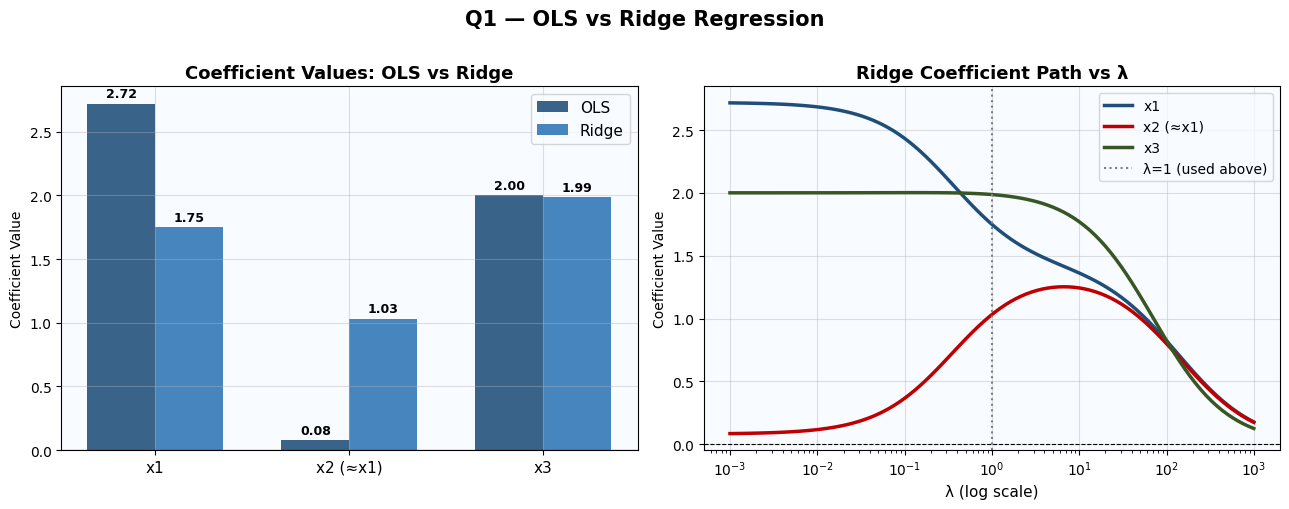


⚠  OLS: x1 & x2 have wildly unstable coefficients due to collinearity.
✅  Ridge: coefficients are shrunk and stabilized.


In [2]:
# ── Q1: OLS vs Ridge — coefficient stability demonstration ──────────────────
np.random.seed(42)
n = 80

# Create a dataset with multicollinearity
x1 = np.random.randn(n)
x2 = x1 + np.random.randn(n) * 0.1   # highly correlated with x1
x3 = np.random.randn(n)
X_mc = np.column_stack([x1, x2, x3])
y_mc = 3*x1 + 2*x3 + np.random.randn(n) * 0.5

sc = StandardScaler()
X_sc = sc.fit_transform(X_mc)

ols   = LinearRegression().fit(X_sc, y_mc)
ridge = Ridge(alpha=1.0).fit(X_sc, y_mc)

features = ['x1', 'x2 (≈x1)', 'x3']
ols_coef   = ols.coef_
ridge_coef = ridge.coef_

print('='*52)
print('  OLS vs Ridge — Coefficient Comparison')
print('='*52)
print(f'  {"Feature":10}  {"OLS":>12}  {"Ridge":>12}')
print('  ' + '-'*38)
for f, o, r in zip(features, ols_coef, ridge_coef):
    print(f'  {f:10}  {o:12.4f}  {r:12.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_pos = np.arange(len(features))
w = 0.35
bars1 = axes[0].bar(x_pos - w/2, ols_coef,   w, label='OLS',   color=C1, alpha=0.88)
bars2 = axes[0].bar(x_pos + w/2, ridge_coef, w, label='Ridge', color=C2, alpha=0.88)
for b, v in zip(list(bars1)+list(bars2), list(ols_coef)+list(ridge_coef)):
    axes[0].text(b.get_x()+b.get_width()/2, v + (0.05 if v>=0 else -0.15),
                 f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(features, fontsize=11)
axes[0].set_title('Coefficient Values: OLS vs Ridge', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Coefficient Value')
axes[0].legend(fontsize=11)

# Ridge shrinkage across lambda values
lambdas = np.logspace(-3, 3, 100)
coef_paths = np.array([Ridge(alpha=a).fit(X_sc, y_mc).coef_ for a in lambdas])
for i, (f, col) in enumerate(zip(features, [C1, C3, C4])):
    axes[1].semilogx(lambdas, coef_paths[:, i], lw=2.5, color=col, label=f)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].axvline(1.0, color='grey', ls=':', lw=1.5, label='λ=1 (used above)')
axes[1].set_xlabel('λ (log scale)', fontsize=11)
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Ridge Coefficient Path vs λ', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Q1 — OLS vs Ridge Regression', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('\n⚠  OLS: x1 & x2 have wildly unstable coefficients due to collinearity.')
print('✅  Ridge: coefficients are shrunk and stabilized.')


---
## Q2 — What are the Assumptions of Ridge Regression?


### 📖 Theory

Ridge Regression **relaxes** the strict OLS assumption of no multicollinearity,
but retains several core assumptions:

| # | Assumption | Ridge vs OLS |
|---|------------|--------------|
| 1 | **Linearity** — relationship between X and y is linear | Same as OLS |
| 2 | **Independence** — observations are independent | Same as OLS |
| 3 | **Homoscedasticity** — constant variance of residuals | Same as OLS |
| 4 | **Normality of residuals** — errors ~ N(0, σ²) | Same as OLS |
| 5 | **No perfect multicollinearity** | **Relaxed** — Ridge handles multicollinearity |
| 6 | **Feature scaling** | **Additional** — Ridge requires standardized features |

> 🔑 **Key difference:** Ridge does NOT require features to be uncorrelated.  
> It stabilizes estimation even when $X^TX$ is near-singular.


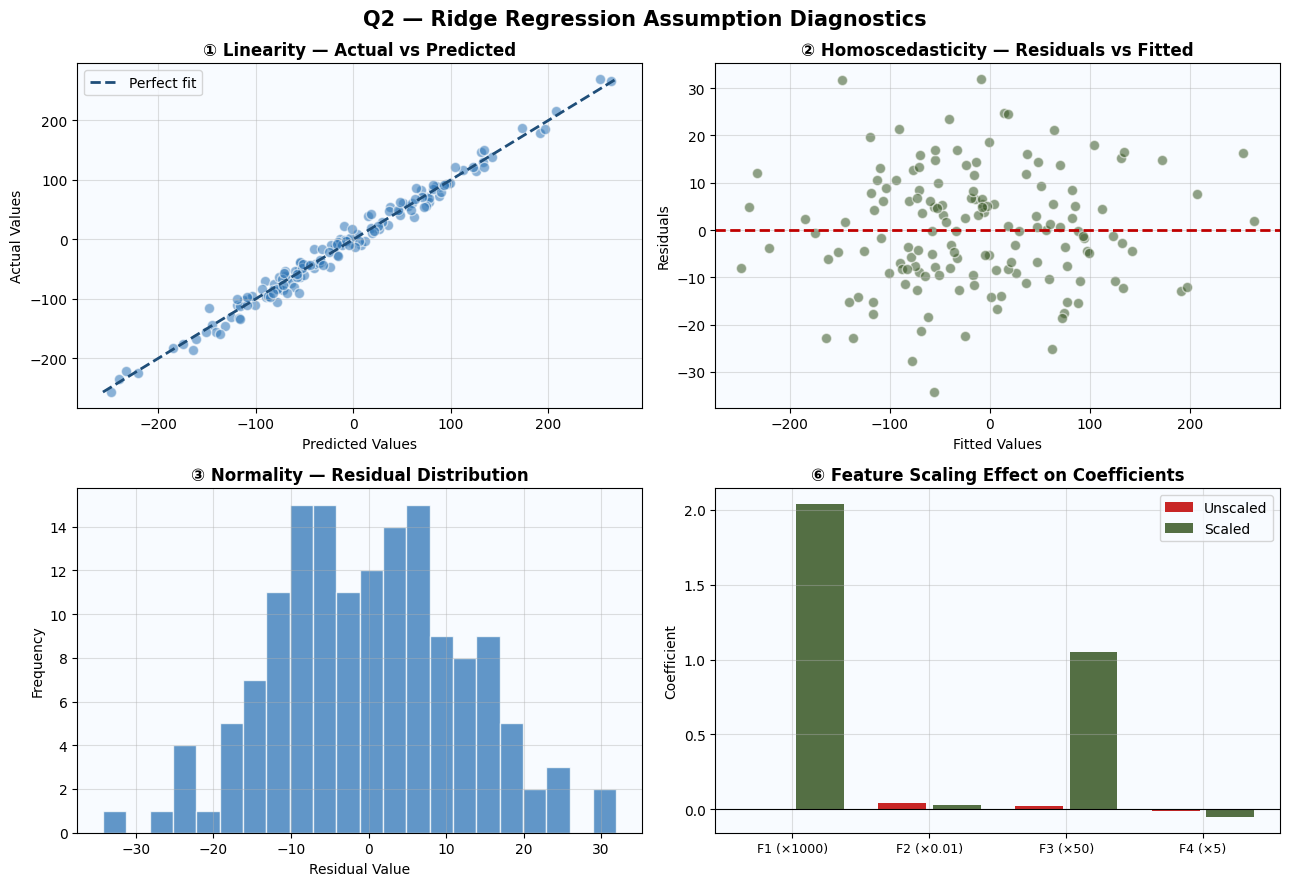

In [3]:
# ── Q2: Visual diagnostic of Ridge assumptions ──────────────────────────────
np.random.seed(0)
n = 150
X2, y2 = make_regression(n_samples=n, n_features=4, noise=12, random_state=0)
sc2 = StandardScaler()
X2s = sc2.fit_transform(X2)

model2 = Ridge(alpha=1.0).fit(X2s, y2)
y2_pred = model2.predict(X2s)
residuals = y2 - y2_pred

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Linearity — Actual vs Predicted
axes[0,0].scatter(y2_pred, y2, alpha=0.55, color=C2, edgecolors='white', s=55)
mn, mx = min(y2.min(), y2_pred.min()), max(y2.max(), y2_pred.max())
axes[0,0].plot([mn,mx],[mn,mx],'--', color=C1, lw=2, label='Perfect fit')
axes[0,0].set_xlabel('Predicted Values'); axes[0,0].set_ylabel('Actual Values')
axes[0,0].set_title('① Linearity — Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0,0].legend()

# 2. Homoscedasticity — Residuals vs Fitted
axes[0,1].scatter(y2_pred, residuals, alpha=0.55, color=C4, edgecolors='white', s=55)
axes[0,1].axhline(0, color=C3, lw=2, ls='--')
axes[0,1].set_xlabel('Fitted Values'); axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('② Homoscedasticity — Residuals vs Fitted', fontsize=12, fontweight='bold')

# 3. Normality — Residual histogram
axes[1,0].hist(residuals, bins=22, color=C2, alpha=0.75, edgecolor='white')
from numpy.random import normal
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
axes[1,0].set_xlabel('Residual Value'); axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('③ Normality — Residual Distribution', fontsize=12, fontweight='bold')

# 4. Feature scaling illustration
X_unscaled = np.column_stack([
    np.random.randn(n)*1000,
    np.random.randn(n)*0.01,
    np.random.randn(n)*50,
    np.random.randn(n)*5
])
y_sc_test = 2*X_unscaled[:,0]/1000 + X_unscaled[:,2]/50 + np.random.randn(n)
X_sc_test = StandardScaler().fit_transform(X_unscaled)

coef_unscaled = Ridge(alpha=1.0).fit(X_unscaled, y_sc_test).coef_
coef_scaled   = Ridge(alpha=1.0).fit(X_sc_test,   y_sc_test).coef_
feat_labels   = ['F1 (×1000)', 'F2 (×0.01)', 'F3 (×50)', 'F4 (×5)']

x4 = np.arange(4)
axes[1,1].bar(x4 - 0.2, coef_unscaled, 0.35, color=C3, alpha=0.85, label='Unscaled')
axes[1,1].bar(x4 + 0.2, coef_scaled,   0.35, color=C4, alpha=0.85, label='Scaled')
axes[1,1].axhline(0, color='black', lw=0.8)
axes[1,1].set_xticks(x4); axes[1,1].set_xticklabels(feat_labels, fontsize=9)
axes[1,1].set_title('⑥ Feature Scaling Effect on Coefficients', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Coefficient'); axes[1,1].legend(fontsize=10)

plt.suptitle('Q2 — Ridge Regression Assumption Diagnostics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Q3 — How do you select the tuning parameter (λ) in Ridge Regression?


### 📖 Theory

**λ (lambda)** controls the strength of the penalty:
- **λ → 0:** Ridge approaches OLS (no regularization)
- **λ → ∞:** All coefficients shrink to zero (underfitting)

#### Selection Methods

| Method | Description | Pros | Cons |
|--------|-------------|------|------|
| **k-Fold CV** | Grid search over λ values, pick lowest CV error | Reliable | Computationally heavy |
| **RidgeCV** | Built-in sklearn efficient cross-validation | Fast, built-in | Less flexible |
| **GCV** | Generalized Cross-Validation (closed form) | No data split needed | Assumes Gaussian errors |
| **Elbow / L-curve** | Plot test error vs λ, pick elbow | Visual, intuitive | Subjective |

> ✅ **Best practice:** Use `RidgeCV` or `k-Fold CV` with a logarithmic grid of λ values.


      Lambda Selection Results
  Manual 5-Fold CV best λ : 0.26827
  RidgeCV best λ          : 0.36562
  Test-error best λ       : 2.73511
  Test RMSE (optimal λ)   : 22.7148


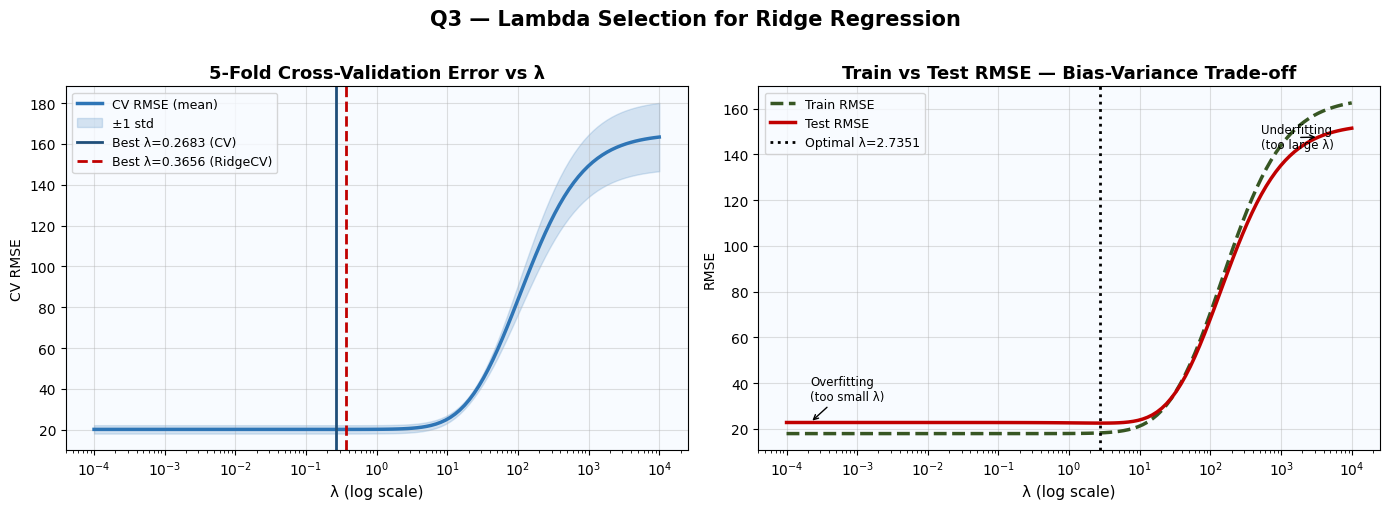

In [4]:
# ── Q3: Lambda selection via Cross-Validation ───────────────────────────────
np.random.seed(42)
X3, y3 = make_regression(n_samples=200, n_features=15, n_informative=8,
                          noise=20, random_state=42)
X3_tr, X3_te, y3_tr, y3_te = train_test_split(X3, y3, test_size=0.25, random_state=1)
sc3 = StandardScaler()
X3_tr_s = sc3.fit_transform(X3_tr)
X3_te_s = sc3.transform(X3_te)

lambdas = np.logspace(-4, 4, 120)

# ── Method 1: Manual k-Fold CV ───────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=7)
cv_means, cv_stds = [], []
for lam in lambdas:
    scores = cross_val_score(Ridge(alpha=lam), X3_tr_s, y3_tr,
                             cv=kf, scoring='neg_root_mean_squared_error')
    cv_means.append(-scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)
best_lam_cv = lambdas[np.argmin(cv_means)]

# ── Method 2: RidgeCV (sklearn built-in) ─────────────────────────────────────
rcv = RidgeCV(alphas=lambdas, cv=5).fit(X3_tr_s, y3_tr)
best_lam_rcv = rcv.alpha_

# ── Test error across lambda ─────────────────────────────────────────────────
test_rmse = [np.sqrt(mean_squared_error(y3_te, Ridge(alpha=a).fit(X3_tr_s,y3_tr).predict(X3_te_s)))
             for a in lambdas]
best_lam_test = lambdas[np.argmin(test_rmse)]

print('='*55)
print('      Lambda Selection Results')
print('='*55)
print(f'  Manual 5-Fold CV best λ : {best_lam_cv:.5f}')
print(f'  RidgeCV best λ          : {best_lam_rcv:.5f}')
print(f'  Test-error best λ       : {best_lam_test:.5f}')

best = Ridge(alpha=best_lam_rcv).fit(X3_tr_s, y3_tr)
print(f'  Test RMSE (optimal λ)   : {np.sqrt(mean_squared_error(y3_te, best.predict(X3_te_s))):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV error curve
axes[0].semilogx(lambdas, cv_means, color=C2, lw=2.5, label='CV RMSE (mean)')
axes[0].fill_between(lambdas, cv_means-cv_stds, cv_means+cv_stds,
                      alpha=0.18, color=C2, label='±1 std')
axes[0].axvline(best_lam_cv,  color=C1, ls='-',  lw=2, label=f'Best λ={best_lam_cv:.4f} (CV)')
axes[0].axvline(best_lam_rcv, color=C3, ls='--', lw=2, label=f'Best λ={best_lam_rcv:.4f} (RidgeCV)')
axes[0].set_xlabel('λ (log scale)', fontsize=11); axes[0].set_ylabel('CV RMSE')
axes[0].set_title('5-Fold Cross-Validation Error vs λ', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# Train vs Test RMSE
train_rmse = [np.sqrt(mean_squared_error(y3_tr, Ridge(alpha=a).fit(X3_tr_s,y3_tr).predict(X3_tr_s)))
              for a in lambdas]
axes[1].semilogx(lambdas, train_rmse, color=C4, lw=2.5, ls='--', label='Train RMSE')
axes[1].semilogx(lambdas, test_rmse,  color=C3, lw=2.5, label='Test RMSE')
axes[1].axvline(best_lam_test, color='black', ls=':', lw=2, label=f'Optimal λ={best_lam_test:.4f}')
axes[1].set_xlabel('λ (log scale)', fontsize=11); axes[1].set_ylabel('RMSE')
axes[1].set_title('Train vs Test RMSE — Bias-Variance Trade-off', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].annotate('Underfitting\n(too large λ)', xy=(lambdas[-8], test_rmse[-8]),
                  xytext=(lambdas[-20], test_rmse[-8]-5), fontsize=8.5,
                  arrowprops=dict(arrowstyle='->', color='black'))
axes[1].annotate('Overfitting\n(too small λ)', xy=(lambdas[5], test_rmse[5]),
                  xytext=(lambdas[5], test_rmse[5]+10), fontsize=8.5,
                  arrowprops=dict(arrowstyle='->', color='black'))

plt.suptitle('Q3 — Lambda Selection for Ridge Regression', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q4 — Can Ridge Regression be used for Feature Selection?


### 📖 Theory

**Short answer: No — not directly.**

Ridge uses an **L2 penalty** which shrinks all coefficients toward zero *but never to exactly zero*.  
This means Ridge **keeps all features** — it is not a sparse method.

#### Ridge vs Lasso for Feature Selection

| Property | Ridge (L2) | Lasso (L1) |
|----------|-----------|------------|
| Coefficients reach zero? | ❌ No | ✅ Yes |
| Feature selection | ❌ Not directly | ✅ Yes |
| Geometry | Circular constraint | Diamond constraint |
| When a feature is irrelevant | Coefficient shrinks but stays | Coefficient → exactly 0 |

#### Indirect Feature Selection with Ridge
- Use coefficient **magnitudes** as a relevance ranking
- Apply a **threshold** (e.g. |β| < ε → discard)
- Use **Elastic Net** (L1+L2) for true selection + Ridge stability


  Feature Selection Comparison: Ridge vs Lasso
  Ridge — Non-zero coefficients  :  20 / 20
  Lasso — Non-zero coefficients  :   6 / 20
  True informative features      :   6 / 20

  Ridge indirect selection (top 40% by |coef|): 8 features
  Selected feature indices: [ 1  6  8  9 13 16 18 19]


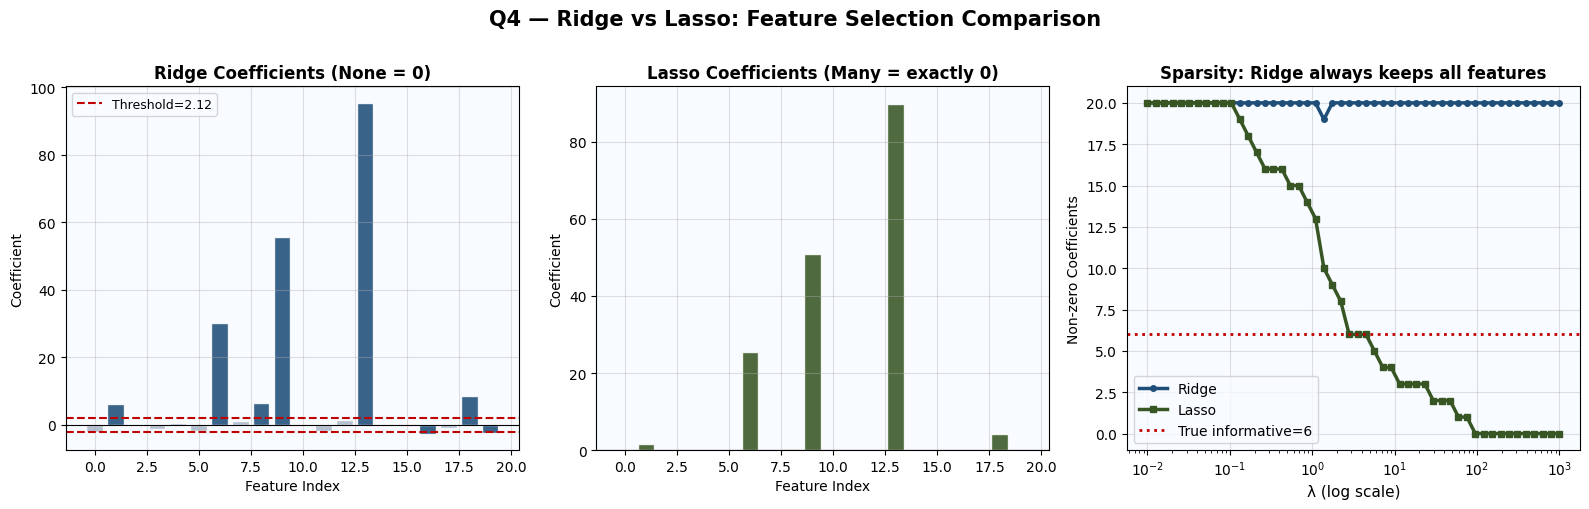

In [5]:
# ── Q4: Ridge vs Lasso feature selection comparison ─────────────────────────
from sklearn.linear_model import Lasso

np.random.seed(42)
n4, p4 = 120, 20
X4, y4, coef4 = make_regression(n_samples=n4, n_features=p4,
                                  n_informative=6, noise=15,
                                  coef=True, random_state=42)
sc4 = StandardScaler()
X4s = sc4.fit_transform(X4)

ridge4 = Ridge(alpha=1.0).fit(X4s, y4)
lasso4 = Lasso(alpha=5.0, max_iter=10000).fit(X4s, y4)

r_coef = ridge4.coef_
l_coef = lasso4.coef_

print('='*60)
print('  Feature Selection Comparison: Ridge vs Lasso')
print('='*60)
print(f'  Ridge — Non-zero coefficients  : {np.sum(np.abs(r_coef) > 1e-4):>3} / {p4}')
print(f'  Lasso — Non-zero coefficients  : {np.sum(np.abs(l_coef) > 1e-4):>3} / {p4}')
print(f'  True informative features      :   6 / {p4}')

# Indirect feature selection via Ridge threshold
threshold = np.percentile(np.abs(r_coef), 60)
selected  = np.where(np.abs(r_coef) > threshold)[0]
print(f'\n  Ridge indirect selection (top 40% by |coef|): {len(selected)} features')
print(f'  Selected feature indices: {selected}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
feat_idx = np.arange(p4)

# Ridge coefficients
colors_r = [C1 if abs(c) > threshold else '#ADB9CA' for c in r_coef]
bars_r = axes[0].bar(feat_idx, r_coef, color=colors_r, alpha=0.88, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axhline( threshold, color=C3, ls='--', lw=1.5, label=f'Threshold={threshold:.2f}')
axes[0].axhline(-threshold, color=C3, ls='--', lw=1.5)
axes[0].set_title('Ridge Coefficients (None = 0)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature Index'); axes[0].set_ylabel('Coefficient')
axes[0].legend(fontsize=9)

# Lasso coefficients
colors_l = [C4 if abs(c) > 1e-4 else '#ADB9CA' for c in l_coef]
axes[1].bar(feat_idx, l_coef, color=colors_l, alpha=0.88, edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Lasso Coefficients (Many = exactly 0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature Index'); axes[1].set_ylabel('Coefficient')

# Sparsity comparison
ridge_nz = [np.sum(np.abs(Ridge(alpha=a).fit(X4s,y4).coef_) > 1e-4) for a in np.logspace(-2,3,50)]
lasso_nz = [np.sum(np.abs(Lasso(alpha=a,max_iter=10000).fit(X4s,y4).coef_) > 1e-4)
            for a in np.logspace(-2,3,50)]
alphas50 = np.logspace(-2, 3, 50)
axes[2].semilogx(alphas50, ridge_nz, 'o-', color=C1, lw=2.5, ms=4, label='Ridge')
axes[2].semilogx(alphas50, lasso_nz, 's-', color=C4, lw=2.5, ms=4, label='Lasso')
axes[2].axhline(6, color=C3, ls=':', lw=2, label='True informative=6')
axes[2].set_xlabel('λ (log scale)', fontsize=11); axes[2].set_ylabel('Non-zero Coefficients')
axes[2].set_title('Sparsity: Ridge always keeps all features', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)

plt.suptitle('Q4 — Ridge vs Lasso: Feature Selection Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q5 — How does Ridge Regression perform in the presence of Multicollinearity?


### 📖 Theory

**Multicollinearity** occurs when two or more predictors are highly correlated.  
This inflates the variance of OLS coefficient estimates, making them unreliable.

#### Why OLS Fails
When $X^TX$ is near-singular (highly correlated features), $(X^TX)^{-1}$ becomes numerically unstable → **huge, erratic coefficients**.

#### How Ridge Fixes It
Ridge adds $\lambda I$ to $X^TX$ before inverting:  
$$\hat{\beta}_{Ridge} = (X^TX + \lambda I)^{-1}X^Ty$$

This ensures the matrix is **always invertible** and coefficients are **stable**.  

#### Variance Inflation Factor (VIF)
$$VIF_j = \frac{1}{1 - R^2_j}$$
High VIF (> 5–10) indicates multicollinearity.  Ridge is the go-to fix.


  Coefficient Variance vs Correlation (80 repetitions)
   Correlation       OLS Var     Ridge Var   Reduction
  --------------------------------------------------
          0.00        0.0358        0.0325        9.2%
          0.50        0.0397        0.0346       12.8%
          0.85        0.0747        0.0438       41.3%
          0.95        0.2543        0.0583       77.1%
          0.99        1.0074        0.0329       96.7%


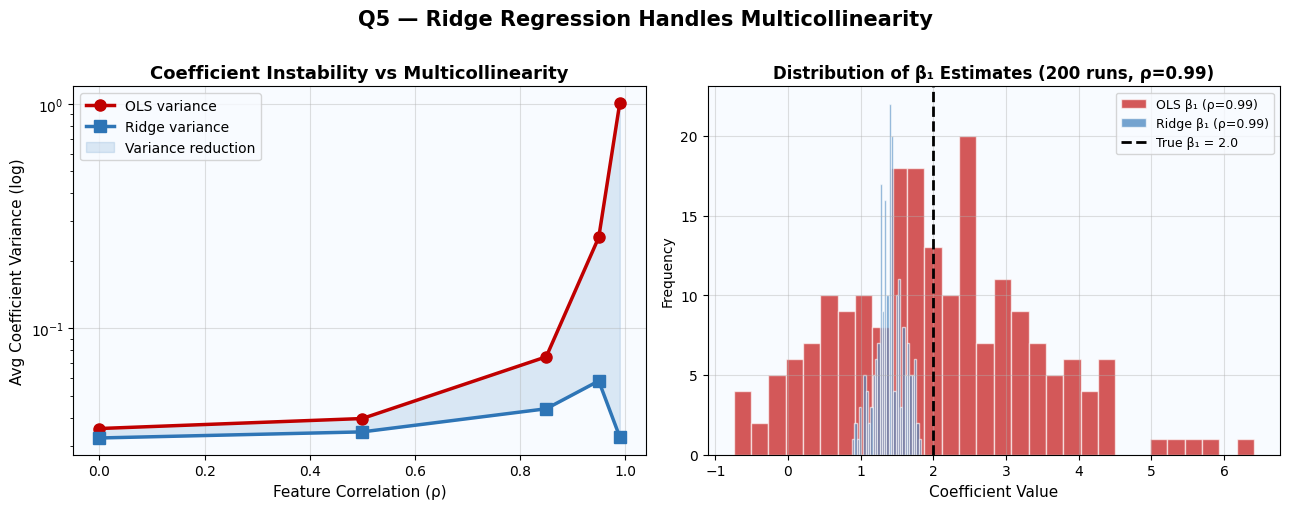

In [6]:
# ── Q5: Multicollinearity — OLS vs Ridge stability ──────────────────────────
np.random.seed(42)
n5 = 100

# Build datasets with varying correlation levels
correlations = [0.0, 0.5, 0.85, 0.95, 0.99]
ols_var, ridge_var = [], []

for rho in correlations:
    cov = [[1, rho, rho/2], [rho, 1, rho/3], [rho/2, rho/3, 1]]
    ols_coefs_rep, ridge_coefs_rep = [], []
    for _ in range(80):  # repeat to estimate variance
        X5 = np.random.multivariate_normal([0,0,0], cov, n5)
        y5 = 2*X5[:,0] + X5[:,1] - 0.5*X5[:,2] + np.random.randn(n5)*1.5
        X5s = StandardScaler().fit_transform(X5)
        ols_coefs_rep.append(LinearRegression().fit(X5s,y5).coef_)
        ridge_coefs_rep.append(Ridge(alpha=5.0).fit(X5s,y5).coef_)
    ols_var.append(np.var(np.array(ols_coefs_rep), axis=0).mean())
    ridge_var.append(np.var(np.array(ridge_coefs_rep), axis=0).mean())

print('='*58)
print('  Coefficient Variance vs Correlation (80 repetitions)')
print('='*58)
print(f'  {"Correlation":>12}  {"OLS Var":>12}  {"Ridge Var":>12}  {"Reduction":>10}')
print('  ' + '-'*50)
for rho, ov, rv in zip(correlations, ols_var, ridge_var):
    red = (1 - rv/ov) * 100 if ov > 0 else 0
    print(f'  {rho:>12.2f}  {ov:>12.4f}  {rv:>12.4f}  {red:>9.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Variance vs correlation
axes[0].semilogy(correlations, ols_var,   'o-', color=C3, lw=2.5, ms=8, label='OLS variance')
axes[0].semilogy(correlations, ridge_var, 's-', color=C2, lw=2.5, ms=8, label='Ridge variance')
axes[0].fill_between(correlations, ols_var, ridge_var, alpha=0.15, color=C2, label='Variance reduction')
axes[0].set_xlabel('Feature Correlation (ρ)', fontsize=11)
axes[0].set_ylabel('Avg Coefficient Variance (log)', fontsize=11)
axes[0].set_title('Coefficient Instability vs Multicollinearity', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Coefficient distribution at rho=0.99
rho_high = 0.99
cov_high = [[1,rho_high,rho_high/2],[rho_high,1,rho_high/3],[rho_high/2,rho_high/3,1]]
ols_c99, rid_c99 = [], []
for _ in range(200):
    X99 = np.random.multivariate_normal([0,0,0], cov_high, n5)
    y99 = 2*X99[:,0]+X99[:,1]-0.5*X99[:,2]+np.random.randn(n5)*1.5
    X99s = StandardScaler().fit_transform(X99)
    ols_c99.append(LinearRegression().fit(X99s,y99).coef_[0])
    rid_c99.append(Ridge(alpha=5.0).fit(X99s,y99).coef_[0])

axes[1].hist(ols_c99, bins=30, color=C3, alpha=0.65, edgecolor='white', label='OLS β₁ (ρ=0.99)')
axes[1].hist(rid_c99, bins=30, color=C2, alpha=0.65, edgecolor='white', label='Ridge β₁ (ρ=0.99)')
axes[1].axvline(2.0, color='black', lw=2, ls='--', label='True β₁ = 2.0')
axes[1].set_xlabel('Coefficient Value', fontsize=11); axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of β₁ Estimates (200 runs, ρ=0.99)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Q5 — Ridge Regression Handles Multicollinearity', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q6 — Can Ridge Regression handle both Categorical and Continuous variables?


### 📖 Theory

**Yes** — Ridge Regression can handle both variable types, but **categorical variables must be encoded**
before fitting since Ridge (like all linear models) requires numerical input.

#### Encoding Strategies

| Type | Method | Notes |
|------|--------|-------|
| Binary categorical | Label Encoding (0/1) | Simple, no dummy trap |
| Nominal (no order) | **One-Hot Encoding** | Drop one category to avoid perfect multicollinearity |
| Ordinal (ordered) | Ordinal / Integer Encoding | Preserves order |
| High-cardinality | Target Encoding | Reduces dimensionality |

> ⚠️ **Always scale continuous features** before applying Ridge.  
> Dummy (0/1) variables don't necessarily need scaling but consistency is recommended.


Dataset Preview:
 age       income  experience gender        dept       salary
60.0 51785.132751        19.0 Female Engineering 72191.269192
50.0 44662.086843        18.0   Male          HR 54978.700119
36.0 65917.496712        25.0   Male Engineering 75608.197951
64.0 45713.959595        14.0   Male     Finance 63335.801701
29.0 60342.397456        15.0   Male Engineering 64541.629545
42.0 54671.786885        20.0 Female          HR 58473.640282

Shape: (200, 6) | Dtypes:
age           float64
income        float64
experience    float64
gender         object
dept           object
salary        float64

✅ Ridge with Mixed Features:
   Test RMSE : 5,994
   Test R²   : 0.7924


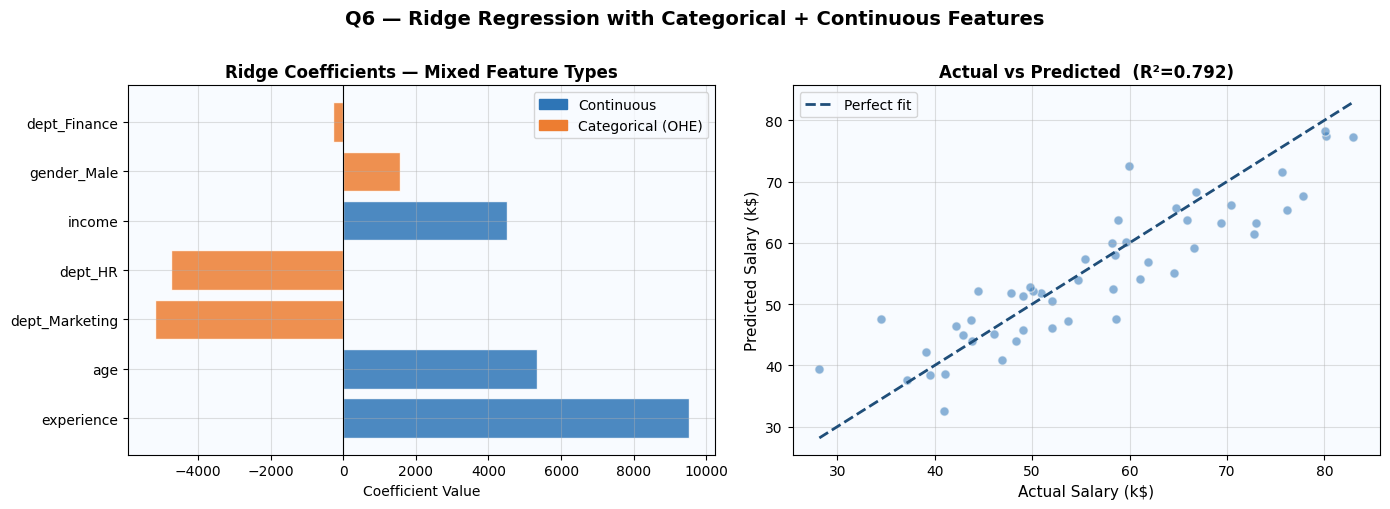

In [7]:
# ── Q6: Ridge with categorical + continuous features ─────────────────────────
np.random.seed(42)
n6 = 200

# Build a realistic mixed dataset
age        = np.random.randint(22, 65, n6).astype(float)
income     = np.random.normal(55000, 15000, n6)
experience = np.random.randint(0, 30, n6).astype(float)
gender     = np.random.choice(['Male', 'Female'], n6)
dept       = np.random.choice(['Engineering', 'Marketing', 'Finance', 'HR'], n6)

# Salary = true relationship
salary = (age * 400 + income * 0.3 + experience * 1200
          + (gender == 'Male') * 3000
          + (dept == 'Engineering') * 8000
          + (dept == 'Finance') * 5000
          + np.random.randn(n6) * 5000)

df6 = pd.DataFrame({'age': age, 'income': income, 'experience': experience,
                     'gender': gender, 'dept': dept, 'salary': salary})

print('Dataset Preview:')
print(df6.head(6).to_string(index=False))
print(f'\nShape: {df6.shape} | Dtypes:')
print(df6.dtypes.to_string())

# Preprocessing pipeline
continuous_features  = ['age', 'income', 'experience']
categorical_features = ['gender', 'dept']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), continuous_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

ridge_pipe = Pipeline([('prep', preprocessor), ('ridge', Ridge(alpha=10.0))])

X6 = df6.drop('salary', axis=1)
y6 = df6['salary']
X6_tr, X6_te, y6_tr, y6_te = train_test_split(X6, y6, test_size=0.25, random_state=0)

ridge_pipe.fit(X6_tr, y6_tr)
y6_pred = ridge_pipe.predict(X6_te)

rmse6 = np.sqrt(mean_squared_error(y6_te, y6_pred))
r2_6  = r2_score(y6_te, y6_pred)
print(f'\n✅ Ridge with Mixed Features:')
print(f'   Test RMSE : {rmse6:,.0f}')
print(f'   Test R²   : {r2_6:.4f}')

# Extract feature names and coefficients
ohe_cats = ridge_pipe.named_steps['prep'].named_transformers_['cat'] \
                     .get_feature_names_out(categorical_features)
feat_names = continuous_features + list(ohe_cats)
coefs6 = ridge_pipe.named_steps['ridge'].coef_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficient bar chart
colors6 = [C2 if f in continuous_features else C5 for f in feat_names]
sorted_idx = np.argsort(np.abs(coefs6))[::-1]
axes[0].barh(np.array(feat_names)[sorted_idx], coefs6[sorted_idx],
             color=np.array(colors6)[sorted_idx], alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=C2, label='Continuous'), Patch(color=C5, label='Categorical (OHE)')],
               fontsize=10)
axes[0].set_title('Ridge Coefficients — Mixed Feature Types', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Value')

# Actual vs Predicted
axes[1].scatter(y6_te/1000, y6_pred/1000, alpha=0.55, color=C2, s=45, edgecolors='white')
mn6, mx6 = y6_te.min()/1000, y6_te.max()/1000
axes[1].plot([mn6,mx6],[mn6,mx6],'--', color=C1, lw=2, label='Perfect fit')
axes[1].set_xlabel('Actual Salary (k$)', fontsize=11)
axes[1].set_ylabel('Predicted Salary (k$)', fontsize=11)
axes[1].set_title(f'Actual vs Predicted  (R²={r2_6:.3f})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Q6 — Ridge Regression with Categorical + Continuous Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q7 — How do you interpret the coefficients of Ridge Regression?


### 📖 Theory

Ridge coefficients are **biased** — they are shrunken versions of the true OLS coefficients.  
This makes interpretation similar to OLS, but with important caveats:

#### Interpretation Rules

| Rule | Detail |
|------|--------|
| **Direction** | Positive β → feature increases y; Negative β → feature decreases y |
| **Magnitude (standardized)** | Larger |β| → stronger association with y |
| **Scaling required** | Coefficients only comparable if features are standardized |
| **Biased estimates** | Ridge β ≠ true β; bias increases with λ |
| **No zero coefficients** | All features retained; smaller coef ≠ zero influence |

#### Effect of λ on Interpretation
$$\hat{\beta}_{Ridge}(\lambda) = \frac{\hat{\beta}_{OLS}}{1 + \lambda/\text{eigenvalue}}$$

> As λ increases, coefficients are shrunk proportionally toward zero.  
> **Never interpret Ridge coefficients as unbiased causal effects.**


Ridge Coefficients at Different λ Values (standardized features):
         Area(m²)  Age(yrs)   Rooms   Floor  Distance(km)  Rating
Lambda                                                           
λ=0        2.7151   -1.1223  1.8654  0.2853       -0.7270  1.5987
λ=0.1      2.7136   -1.1215  1.8643  0.2855       -0.7267  1.5980
λ=1.0      2.7002   -1.1143  1.8546  0.2873       -0.7240  1.5910
λ=5.0      2.6425   -1.0836  1.8127  0.2944       -0.7122  1.5609
λ=20.0     2.4474   -0.9820  1.6717  0.3137       -0.6715  1.4569
λ=100.0    1.7624   -0.6535  1.1869  0.3246       -0.5176  1.0708

True βs: {'Area(m²)': np.float64(3.0), 'Age(yrs)': np.float64(-1.5), 'Rooms': np.float64(2.0), 'Floor': np.float64(0.3), 'Distance(km)': np.float64(-0.8), 'Rating': np.float64(1.2)}


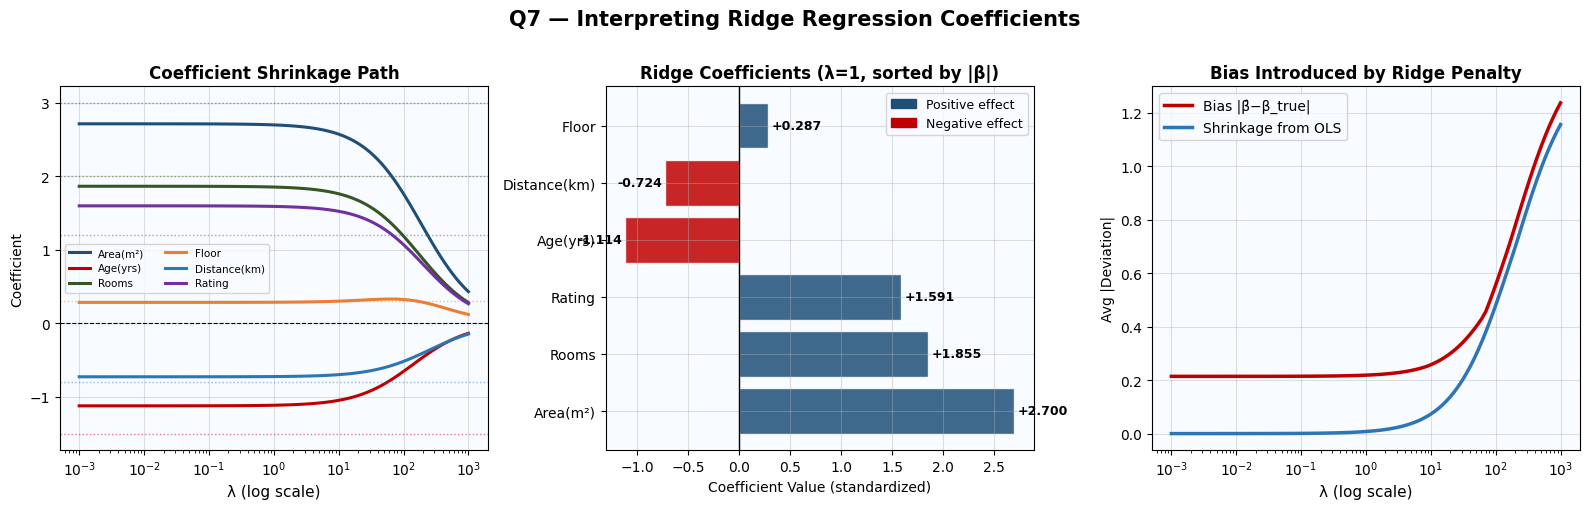

In [8]:
# ── Q7: Coefficient interpretation + bias-lambda relationship ────────────────
np.random.seed(7)
n7 = 180

# Standardized dataset with known true coefficients
true_betas = np.array([3.0, -1.5, 2.0, 0.3, -0.8, 1.2])
feat_names7 = ['Area(m²)', 'Age(yrs)', 'Rooms', 'Floor', 'Distance(km)', 'Rating']
X7 = np.random.randn(n7, 6)
y7 = X7 @ true_betas + np.random.randn(n7) * 2.0

sc7 = StandardScaler()
X7s = sc7.fit_transform(X7)

lambdas7 = [0, 0.1, 1.0, 5.0, 20.0, 100.0]
coef_table = []
for lam in lambdas7:
    if lam == 0:
        m = LinearRegression().fit(X7s, y7)
    else:
        m = Ridge(alpha=lam).fit(X7s, y7)
    coef_table.append(list(m.coef_))

df_coef = pd.DataFrame(coef_table, columns=feat_names7,
                        index=[f'λ={l}' for l in lambdas7])
df_coef.index.name = 'Lambda'
print('Ridge Coefficients at Different λ Values (standardized features):')
print('='*70)
print(df_coef.round(4).to_string())
print(f'\nTrue βs: {dict(zip(feat_names7, true_betas))}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Coefficient paths
lam_path = np.logspace(-3, 3, 100)
path_coefs = np.array([Ridge(alpha=a).fit(X7s,y7).coef_ for a in lam_path])
palette = [C1, C3, C4, C5, C2, '#7030A0']
for i, (f, col) in enumerate(zip(feat_names7, palette)):
    axes[0].semilogx(lam_path, path_coefs[:,i], lw=2.2, color=col, label=f)
    axes[0].axhline(true_betas[i], color=col, ls=':', lw=1, alpha=0.5)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xlabel('λ (log scale)', fontsize=11); axes[0].set_ylabel('Coefficient')
axes[0].set_title('Coefficient Shrinkage Path', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=7.5, ncol=2)

# Magnitude interpretation (optimal model)
best7 = Ridge(alpha=1.0).fit(X7s, y7)
sorted7 = np.argsort(np.abs(best7.coef_))[::-1]
bar_colors = [C1 if c > 0 else C3 for c in best7.coef_[sorted7]]
bars7 = axes[1].barh(np.array(feat_names7)[sorted7], best7.coef_[sorted7],
                      color=bar_colors, alpha=0.85, edgecolor='white')
for bar, v in zip(bars7, best7.coef_[sorted7]):
    axes[1].text(v + (0.03 if v >= 0 else -0.03), bar.get_y()+bar.get_height()/2,
                 f'{v:+.3f}', va='center', ha='left' if v >= 0 else 'right',
                 fontsize=9, fontweight='bold')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Ridge Coefficients (λ=1, sorted by |β|)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coefficient Value (standardized)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=C1,label='Positive effect'),
                          Patch(color=C3,label='Negative effect')], fontsize=9)

# Bias vs lambda
ols_coef7 = LinearRegression().fit(X7s,y7).coef_
bias_vals  = [np.mean(np.abs(Ridge(alpha=a).fit(X7s,y7).coef_ - true_betas)) for a in lam_path]
var_proxy  = [np.mean(np.abs(Ridge(alpha=a).fit(X7s,y7).coef_ - ols_coef7)) for a in lam_path]
axes[2].semilogx(lam_path, bias_vals,  color=C3, lw=2.5, label='Bias |β̂−β_true|')
axes[2].semilogx(lam_path, var_proxy,  color=C2, lw=2.5, label='Shrinkage from OLS')
axes[2].set_xlabel('λ (log scale)', fontsize=11); axes[2].set_ylabel('Avg |Deviation|')
axes[2].set_title('Bias Introduced by Ridge Penalty', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)

plt.suptitle('Q7 — Interpreting Ridge Regression Coefficients', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q8 — Can Ridge Regression be used for Time-Series Data Analysis?


### 📖 Theory

**Yes** — Ridge Regression can be applied to time-series data with proper feature engineering  
and by respecting the **temporal ordering** of observations.

#### Key Adaptations for Time Series

| Adaptation | Why it matters |
|------------|----------------|
| **Lag features** (y_{t-1}, y_{t-2}, ...) | Captures autocorrelation |
| **Rolling statistics** (mean, std) | Captures local trends |
| **Time-based features** (month, weekday, trend) | Handles seasonality |
| **No random train/test split** | Must split chronologically |
| **Time-series cross-validation** | Walk-forward / expanding window |

#### Limitations
- Ridge assumes **independent errors** — violated in time series (autocorrelation)
- Does not model ARIMA-type dynamics natively
- Better suited as a **forecasting baseline** than a standalone time-series model
- For strong seasonality/trend, pair with decomposition or differencing first


  Ridge Regression — Time Series Forecasting
  Optimal λ (walk-forward CV)  : 2.2230
  Features engineered          : 16 (lags + rolling + seasonal)
  Training RMSE                : 1.8957
  Test RMSE                    : 2.1709
  Test MAE                     : 1.7147
  Test R²                      : 0.8599


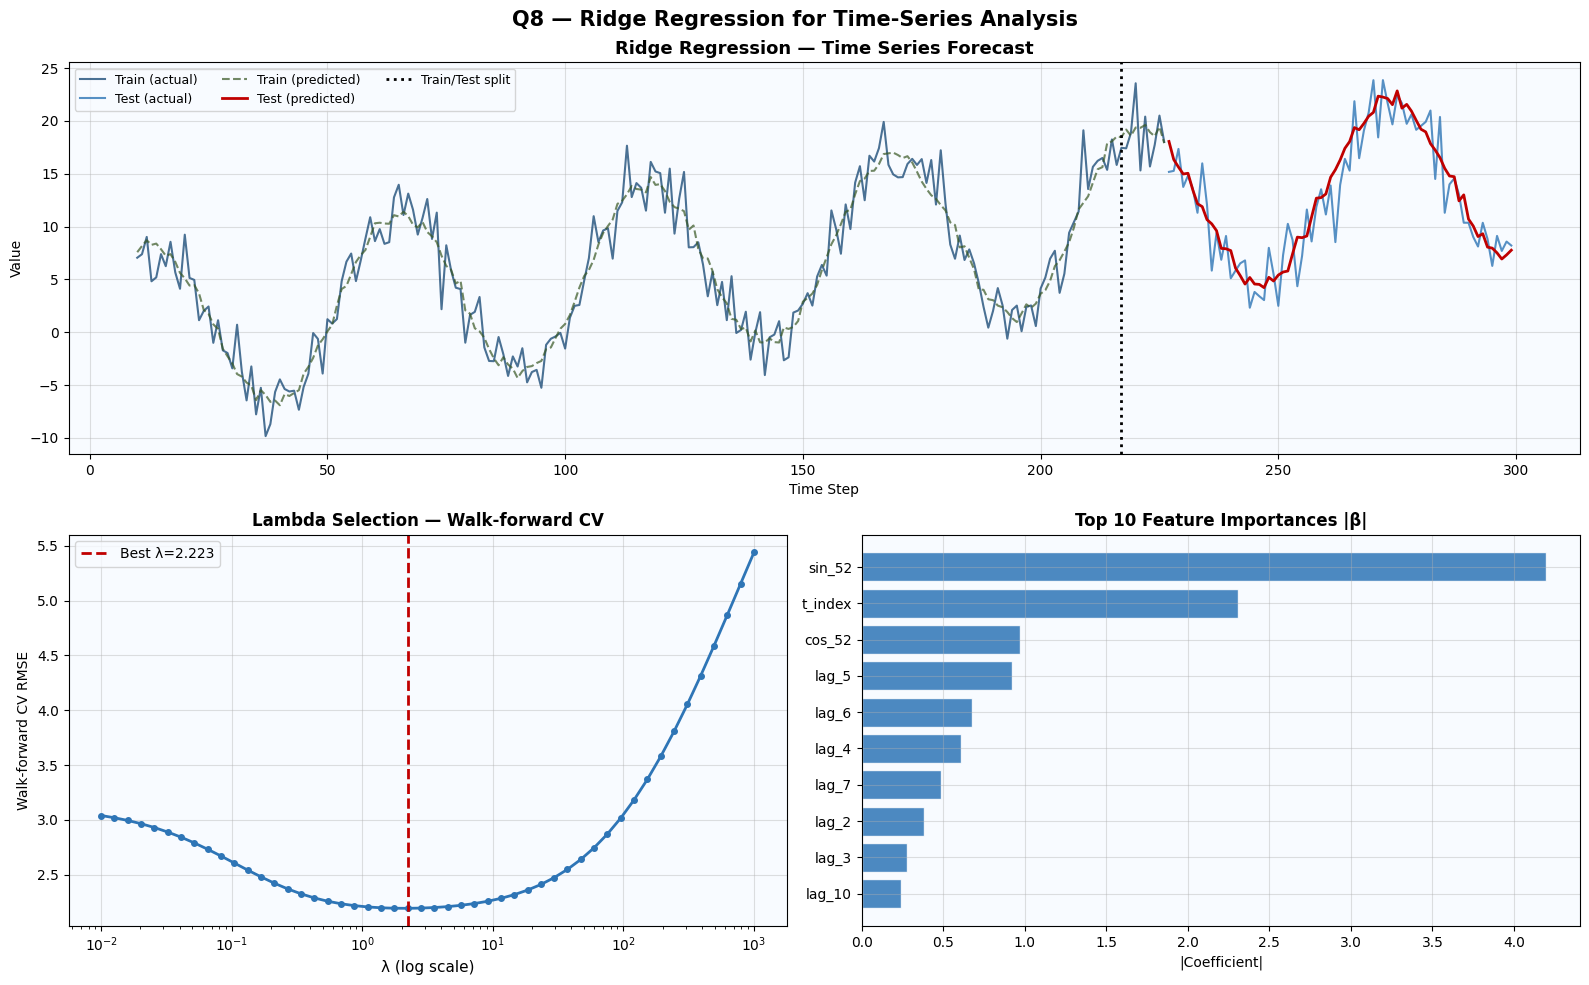

In [9]:
# ── Q8: Ridge for time-series forecasting ────────────────────────────────────
np.random.seed(42)
T = 300  # total timesteps

# Synthetic time series: trend + seasonality + noise
t    = np.arange(T)
trend      = 0.05 * t
seasonality = 8 * np.sin(2 * np.pi * t / 52)   # weekly-like
noise       = np.random.randn(T) * 2
ts = trend + seasonality + noise

# ── Feature engineering ──────────────────────────────────────────────────────
def make_ts_features(series, n_lags=10):
    df = pd.DataFrame({'y': series})
    for lag in range(1, n_lags+1):
        df[f'lag_{lag}'] = df['y'].shift(lag)
    df['roll_mean_5']  = df['y'].shift(1).rolling(5).mean()
    df['roll_std_5']   = df['y'].shift(1).rolling(5).std()
    df['roll_mean_10'] = df['y'].shift(1).rolling(10).mean()
    df['t_index']      = np.arange(len(df))
    df['sin_52']       = np.sin(2*np.pi*np.arange(len(df))/52)
    df['cos_52']       = np.cos(2*np.pi*np.arange(len(df))/52)
    return df.dropna()

df_ts = make_ts_features(ts, n_lags=10)
feat_cols = [c for c in df_ts.columns if c != 'y']

X_ts = df_ts[feat_cols].values
y_ts = df_ts['y'].values

# Chronological split (NEVER random for time series)
split = int(len(X_ts) * 0.75)
X_tr8, X_te8 = X_ts[:split], X_ts[split:]
y_tr8, y_te8 = y_ts[:split], y_ts[split:]

sc8 = StandardScaler()
X_tr8s = sc8.fit_transform(X_tr8)
X_te8s = sc8.transform(X_te8)

# Select best lambda via walk-forward CV
lambdas8  = np.logspace(-2, 3, 50)
wf_errors = []
for lam in lambdas8:
    fold_errors = []
    fold_size = len(X_tr8s) // 5
    for fold in range(1, 5):
        X_wf_tr = X_tr8s[:fold*fold_size]
        y_wf_tr = y_tr8[:fold*fold_size]
        X_wf_val = X_tr8s[fold*fold_size:(fold+1)*fold_size]
        y_wf_val = y_tr8[fold*fold_size:(fold+1)*fold_size]
        m8 = Ridge(alpha=lam).fit(X_wf_tr, y_wf_tr)
        fold_errors.append(np.sqrt(mean_squared_error(y_wf_val, m8.predict(X_wf_val))))
    wf_errors.append(np.mean(fold_errors))

best_lam8 = lambdas8[np.argmin(wf_errors)]
best8 = Ridge(alpha=best_lam8).fit(X_tr8s, y_tr8)
y_pred_tr8 = best8.predict(X_tr8s)
y_pred_te8 = best8.predict(X_te8s)

print('='*52)
print('  Ridge Regression — Time Series Forecasting')
print('='*52)
print(f'  Optimal λ (walk-forward CV)  : {best_lam8:.4f}')
print(f'  Features engineered          : {len(feat_cols)} (lags + rolling + seasonal)')
print(f'  Training RMSE                : {np.sqrt(mean_squared_error(y_tr8, y_pred_tr8)):.4f}')
print(f'  Test RMSE                    : {np.sqrt(mean_squared_error(y_te8, y_pred_te8)):.4f}')
print(f'  Test MAE                     : {mean_absolute_error(y_te8, y_pred_te8):.4f}')
print(f'  Test R²                      : {r2_score(y_te8, y_pred_te8):.4f}')

# Plot
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
full_idx = df_ts.index
ax1.plot(full_idx[:split], y_tr8, color=C1, lw=1.5, alpha=0.8, label='Train (actual)')
ax1.plot(full_idx[split:], y_te8, color=C2, lw=1.5, alpha=0.8, label='Test (actual)')
ax1.plot(full_idx[:split], y_pred_tr8, color=C4, lw=1.5, ls='--', alpha=0.7, label='Train (predicted)')
ax1.plot(full_idx[split:], y_pred_te8, color=C3, lw=2.0, label='Test (predicted)')
ax1.axvline(split, color='black', ls=':', lw=2, label='Train/Test split')
ax1.set_title('Ridge Regression — Time Series Forecast', fontsize=13, fontweight='bold')
ax1.set_xlabel('Time Step'); ax1.set_ylabel('Value'); ax1.legend(fontsize=9, ncol=3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogx(lambdas8, wf_errors, 'o-', color=C2, lw=2, ms=4)
ax2.axvline(best_lam8, color=C3, ls='--', lw=2, label=f'Best λ={best_lam8:.3f}')
ax2.set_xlabel('λ (log scale)', fontsize=11); ax2.set_ylabel('Walk-forward CV RMSE')
ax2.set_title('Lambda Selection — Walk-forward CV', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

ax3 = fig.add_subplot(gs[1, 1])
feat_imp = np.abs(best8.coef_)
sorted_fi = np.argsort(feat_imp)[::-1][:10]
ax3.barh(np.array(feat_cols)[sorted_fi][::-1], feat_imp[sorted_fi][::-1],
          color=C2, alpha=0.85, edgecolor='white')
ax3.set_title('Top 10 Feature Importances |β|', fontsize=12, fontweight='bold')
ax3.set_xlabel('|Coefficient|')

plt.suptitle('Q8 — Ridge Regression for Time-Series Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
